# Sales Data Analytics Notebook

## Problem Statement
Analyze retail sales data to identify:
- Profit leakage areas
- High-value customers
- Impact of discount strategies

## Goal
Improve profitability and customer retention.

This notebook follows a business-first story:
**business problem -> insights -> decisions**.


In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13

## 1) Load Data (Auto-detect Dataset Path)

In [23]:
candidates = [
    # Running from inside sales-analysis/
    Path('data.csv'),
    # Running from project root
    Path('sales-analysis/data.csv'),
    # Running from nested contexts
    Path('../sales-analysis/data.csv'),
    # Optional alternate dataset names/locations
    Path('SampleSuperstore.csv'),
    Path('sales-dashboard/SampleSuperstore.csv'),
]

source_path = None
for p in candidates:
    if p.exists():
        source_path = p
        break

if source_path is None:
    raise FileNotFoundError('No dataset found. Expected data.csv in current folder or sales-analysis/data.csv.')

raw_df = pd.read_csv(source_path)
print(f'Using dataset: {source_path}')
print(f'Rows: {len(raw_df):,} | Columns: {len(raw_df.columns)}')
raw_df.head()

Using dataset: data.csv
Rows: 9,994 | Columns: 19


,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


## 2) Standardize Schema

In [24]:
df = raw_df.copy()

# Case A: SampleSuperstore-style columns already exist
if 'Order Date' in df.columns and 'Product Name' in df.columns:
    pass

# Case B: lowercase/snake-case superstore file (from sales-analysis/data.csv)
elif 'order_date' in df.columns and 'product_name' in df.columns:
    rename_map = {
        'order_id': 'Order ID',
        'order_date': 'Order Date',
        'ship_date': 'Ship Date',
        'customer': 'Customer Name',
        'segment': 'Segment',
        'city': 'City',
        'state': 'State',
        'country': 'Country',
        'region': 'Region',
        'category': 'Category',
        'subcategory': 'Sub-Category',
        'product_name': 'Product Name',
        'sales': 'Sales',
        'quantity': 'Quantity',
        'discount': 'Discount',
        'profit': 'Profit',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
else:
    raise ValueError('Unsupported schema. Expected SampleSuperstore-like columns.')

# Some public SampleSuperstore files do not include Category; keep notebook runnable.
if 'Category' not in df.columns:
    df['Category'] = 'Unspecified'

required_cols = [
    'Order ID', 'Order Date', 'Customer Name', 'Segment', 'Region',
    'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df[required_cols + ['Category']].head()

,Order ID,Order Date,Customer Name,Segment,Region,Product Name,Sales,Quantity,Discount,Profit,Category
0,US-2020-103800,1/3/2019,Darren Powers,Consumer,Central,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,Office Supplies
1,US-2020-112326,1/4/2019,Phillina Ober,Home Office,Central,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,Office Supplies
2,US-2020-112326,1/4/2019,Phillina Ober,Home Office,Central,Avery 508,11.784,3,0.2,4.2717,Office Supplies
3,US-2020-112326,1/4/2019,Phillina Ober,Home Office,Central,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,Office Supplies
4,US-2020-141817,1/5/2019,Mick Brown,Consumer,East,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,Office Supplies


## 3) Cleaning and Feature Engineering

In [25]:
rows_before = len(df)

# Data type fixes
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove nulls in analysis-critical fields and duplicates
critical = ['Order Date', 'Sales', 'Profit', 'Region', 'Product Name', 'Customer Name']
df = df.dropna(subset=critical).drop_duplicates()

# Time features
df['Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
df['Year'] = df['Order Date'].dt.year

rows_after = len(df)
print(f'Rows before: {rows_before:,}')
print(f'Rows after : {rows_after:,}')
print(f'Removed    : {rows_before - rows_after:,}')

Rows before: 9,994
Rows after : 9,993
Removed    : 1


## 4) KPI Snapshot

In [26]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = 100 * total_profit / total_sales if total_sales else 0
orders = df['Order ID'].nunique()
customers = df['Customer Name'].nunique()
aov = total_sales / orders if orders else 0
avg_discount = 100 * df['Discount'].mean()

kpi = pd.DataFrame({
    'Metric': ['Total Sales', 'Total Profit', 'Profit Margin %', 'Unique Orders', 'Unique Customers', 'Average Order Value', 'Average Discount %'],
    'Value': [total_sales, total_profit, profit_margin, orders, customers, aov, avg_discount]
})

kpi.style.format({'Value': '{:,.2f}'})

,Metric,Value
0,Total Sales,"2,296,919.49"
1,Total Profit,"286,409.08"
2,Profit Margin %,12.47
3,Unique Orders,"5,009.00"
4,Unique Customers,793.00
5,Average Order Value,458.56
6,Average Discount %,15.62


## 5) Sales and Profit Trend

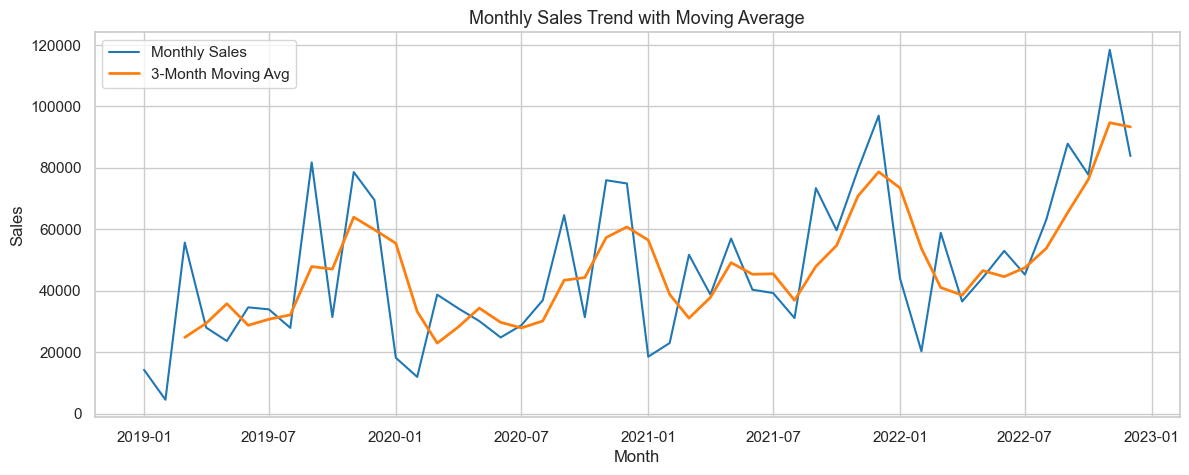

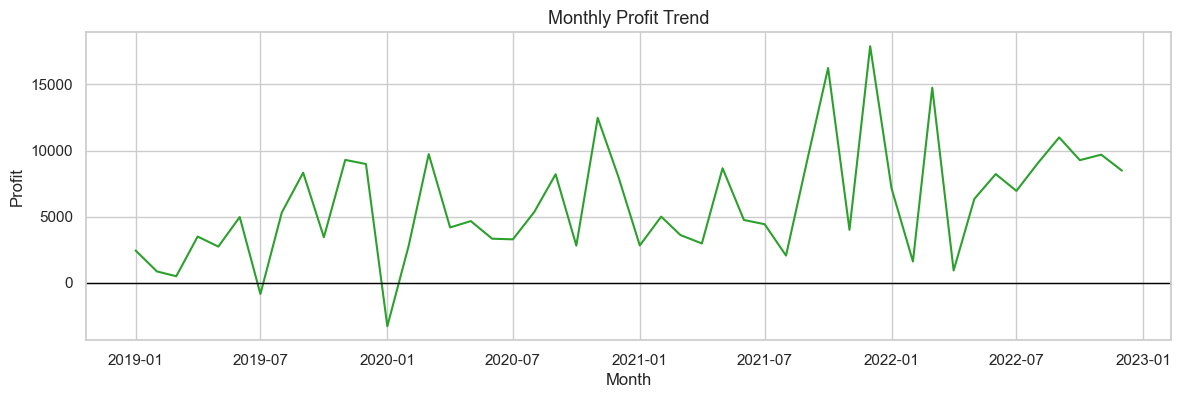

In [27]:
monthly = (
    df.groupby('Month', as_index=False)
      .agg(Monthly_Sales=('Sales', 'sum'), Monthly_Profit=('Profit', 'sum'))
      .sort_values('Month')
)
monthly['Sales_MA_3'] = monthly['Monthly_Sales'].rolling(3).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Monthly_Sales'], label='Monthly Sales', color='tab:blue')
ax.plot(monthly['Month'], monthly['Sales_MA_3'], label='3-Month Moving Avg', color='tab:orange', linewidth=2)
ax.set_title('Monthly Sales Trend with Moving Average')
ax.set_xlabel('Month')
ax.set_ylabel('Sales')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['Month'], monthly['Monthly_Profit'], color='tab:green')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Monthly Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Profit')
plt.show()

## 6) Category and Region Profitability

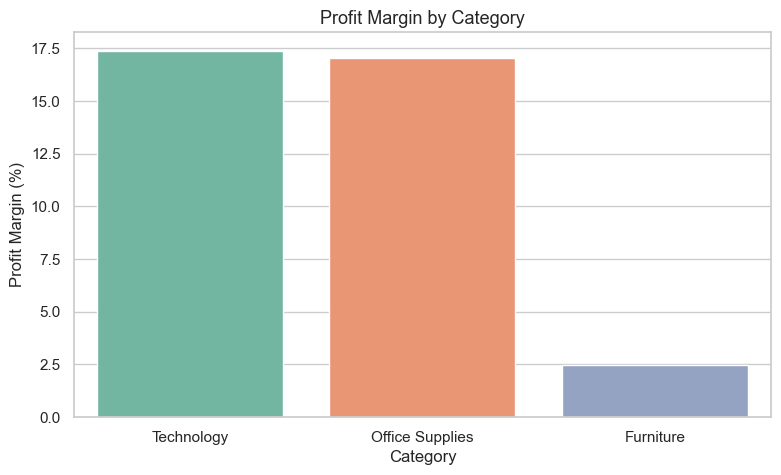

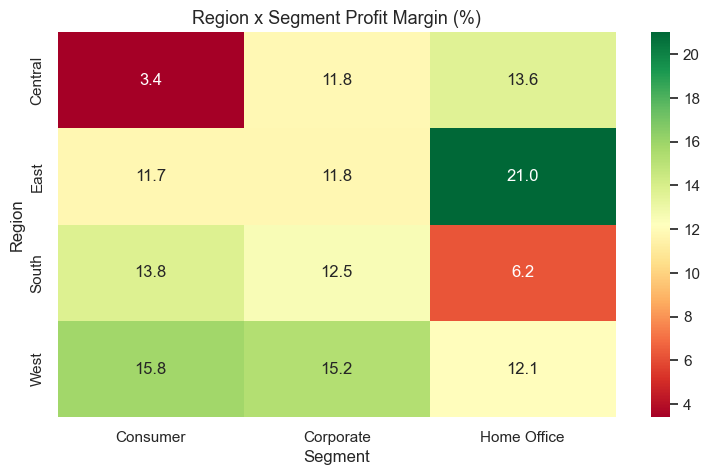

In [28]:
if df['Category'].nunique() <= 1 and (df['Category'].iloc[0] == 'Unspecified'):
    print('Category column is unavailable in this dataset; showing Region-Segment profitability only.')
else:
    cat_perf = (
        df.groupby('Category', as_index=False)
          .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
    )
    cat_perf['Profit_Margin_%'] = 100 * cat_perf['Profit'] / cat_perf['Sales']
    cat_perf = cat_perf.sort_values('Profit_Margin_%', ascending=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=cat_perf, x='Category', y='Profit_Margin_%', hue='Category', legend=False, palette='Set2')
    plt.title('Profit Margin by Category')
    plt.xlabel('Category')
    plt.ylabel('Profit Margin (%)')
    plt.show()

region_segment = (
    df.groupby(['Region', 'Segment'], as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
region_segment['Profit_Margin_%'] = np.where(region_segment['Sales'] != 0, 100 * region_segment['Profit'] / region_segment['Sales'], 0)

heat = region_segment.pivot(index='Region', columns='Segment', values='Profit_Margin_%')
plt.figure(figsize=(9, 5))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Region x Segment Profit Margin (%)')
plt.show()

## 7) Discount Impact Analysis

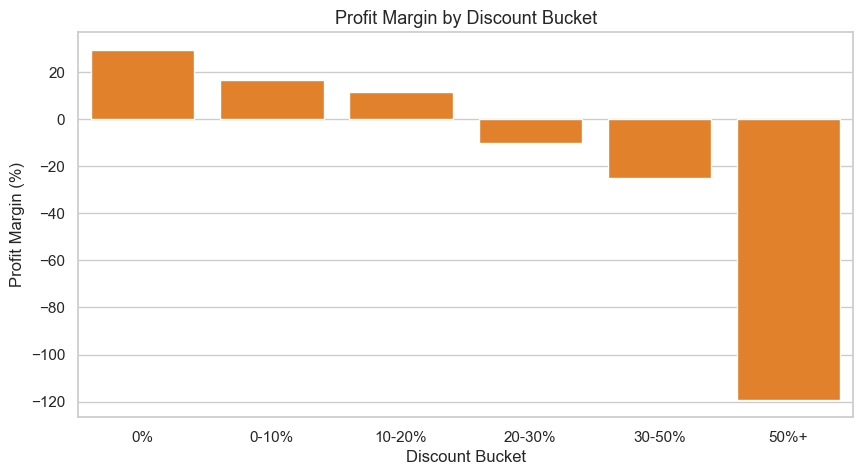

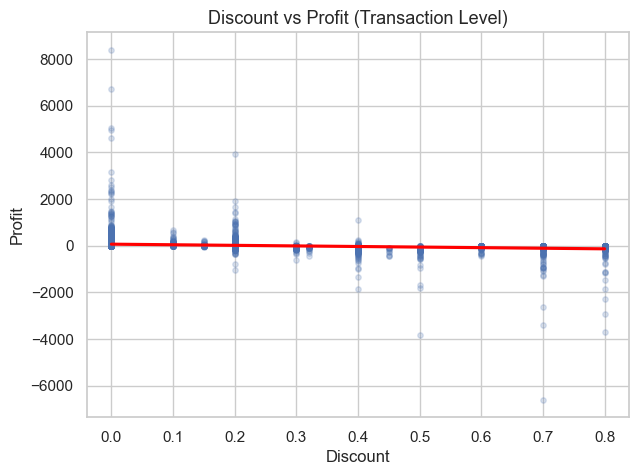

Correlation (Discount, Profit): -0.219


In [29]:
bins = [-0.01, 0.0, 0.1, 0.2, 0.3, 0.5, 0.8]
labels = ['0%', '0-10%', '10-20%', '20-30%', '30-50%', '50%+']
df['Discount Bucket'] = pd.cut(df['Discount'], bins=bins, labels=labels)

disc = (
    df.groupby('Discount Bucket', observed=False, as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
)
disc['Profit_Margin_%'] = np.where(disc['Sales'] != 0, 100 * disc['Profit'] / disc['Sales'], 0)

plt.figure(figsize=(10, 5))
sns.barplot(data=disc, x='Discount Bucket', y='Profit_Margin_%', color='tab:orange')
plt.title('Profit Margin by Discount Bucket')
plt.xlabel('Discount Bucket')
plt.ylabel('Profit Margin (%)')
plt.show()

# Correlation view
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Discount', y='Profit', scatter_kws={'alpha':0.2, 's':15}, line_kws={'color':'red'})
plt.title('Discount vs Profit (Transaction Level)')
plt.show()

print('Correlation (Discount, Profit):', round(df['Discount'].corr(df['Profit']), 3))

## 8) Product Performance: Winners and Loss-Makers

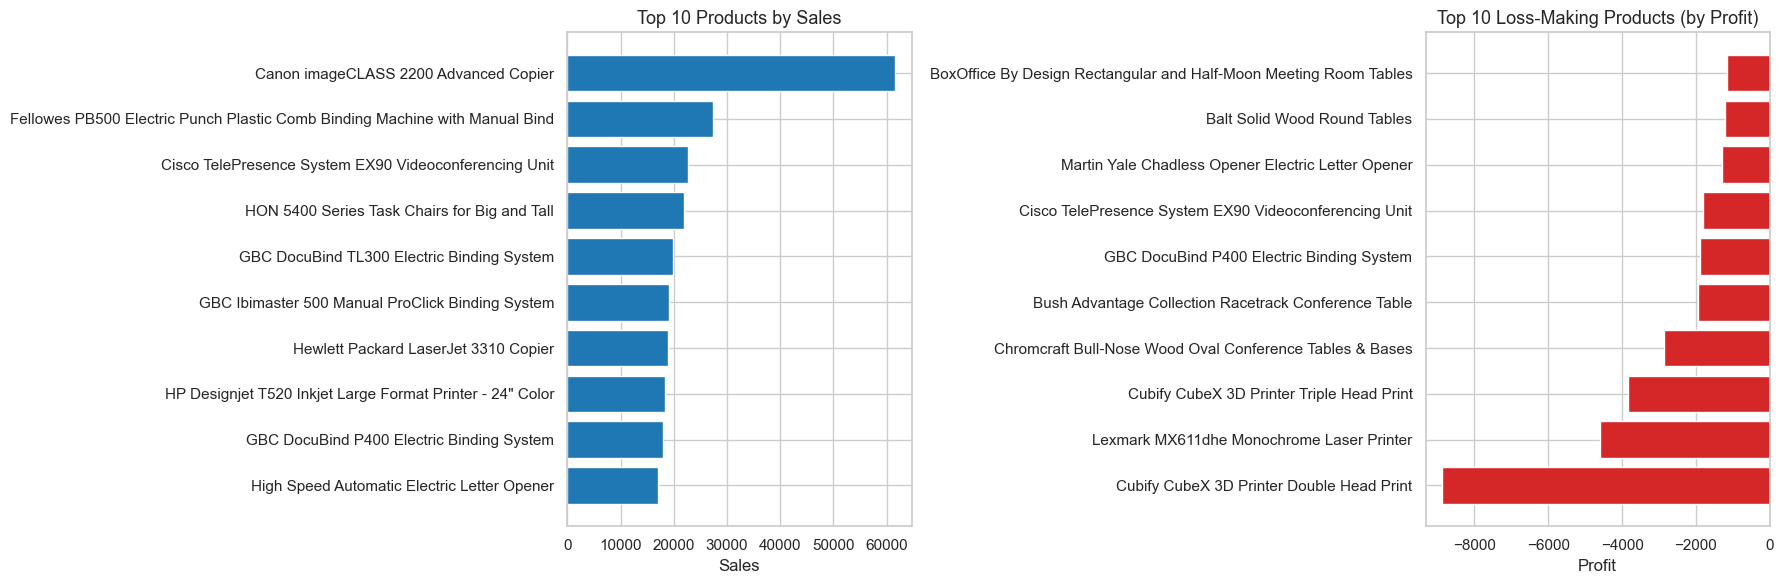

,Product Name,Sales,Profit,Profit_Margin_%
475,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,-80.000000
984,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,-27.272727
476,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,-48.000000
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,-29.000000
376,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,-20.266667
682,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,-10.454545
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,-8.000000
1042,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,-7.800000
285,Balt Solid Wood Round Tables,6518.754,-1201.0581,-18.424658
364,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,-67.307692


In [30]:
product_perf = (
    df.groupby('Product Name', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Quantity=('Quantity', 'sum'))
)
product_perf['Profit_Margin_%'] = np.where(product_perf['Sales'] != 0, 100 * product_perf['Profit'] / product_perf['Sales'], 0)

top_sales = product_perf.sort_values('Sales', ascending=False).head(10).sort_values('Sales')
loss_makers = product_perf.sort_values('Profit').head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].barh(top_sales['Product Name'], top_sales['Sales'], color='tab:blue')
axes[0].set_title('Top 10 Products by Sales')
axes[0].set_xlabel('Sales')

axes[1].barh(loss_makers['Product Name'], loss_makers['Profit'], color='tab:red')
axes[1].set_title('Top 10 Loss-Making Products (by Profit)')
axes[1].set_xlabel('Profit')

plt.tight_layout()
plt.show()

loss_makers[['Product Name', 'Sales', 'Profit', 'Profit_Margin_%']]

## 9) Customer Segmentation (RFM)

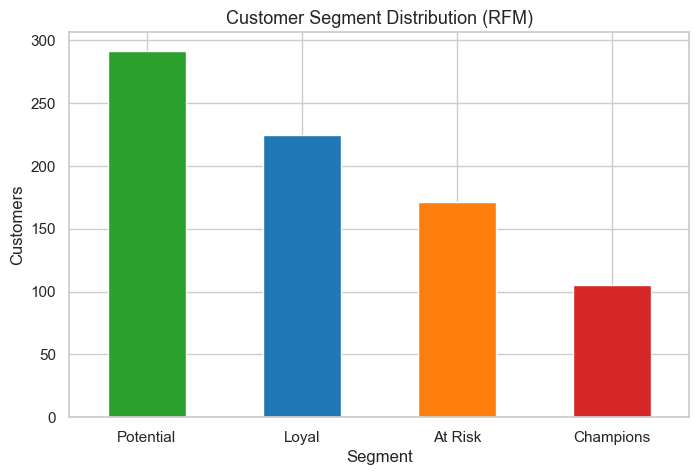

,Customer Name,Recency,Frequency,Monetary,R,F,M,Segment
0,Aaron Bergman,416,3,886.156,1,1,1,At Risk
1,Aaron Hawkins,13,7,1744.700,5,3,3,Loyal
2,Aaron Smayling,89,7,3050.692,3,3,4,Loyal
3,Adam Bellavance,55,8,7755.620,3,4,5,Loyal
4,Adam Hart,35,10,3250.337,4,5,4,Champions


In [31]:
snapshot = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby('Customer Name', as_index=False)
      .agg(
          Recency=('Order Date', lambda x: (snapshot - x.max()).days),
          Frequency=('Order ID', 'nunique'),
          Monetary=('Sales', 'sum')
      )
)

rfm['R'] = pd.qcut(rfm['Recency'].rank(method='first', ascending=False), 5, labels=[1,2,3,4,5]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

def segment(row):
    if row['R'] >= 4 and row['F'] >= 4 and row['M'] >= 4:
        return 'Champions'
    if row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal'
    if row['R'] <= 2 and row['F'] <= 2:
        return 'At Risk'
    return 'Potential'

rfm['Segment'] = rfm.apply(segment, axis=1)
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar', color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red'])
plt.title('Customer Segment Distribution (RFM)')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.show()

rfm.head()

## 10) Business Recommendations

1. Reduce high-discount exposure where margin is consistently weak.
2. Create a remediation plan for recurring loss-making products (pricing, bundling, supplier negotiation).
3. Reallocate campaigns toward region-segment combinations with higher margins.
4. Protect **Champions** and **Loyal** customers with retention offers and build win-back plans for **At Risk** customers.
5. Add a next phase with demand forecasting and experiment tracking (A/B pricing or promotion tests).

## 11) Advanced Visualization Dashboard

This section adds presentation-friendly visuals and exports a combined dashboard image.

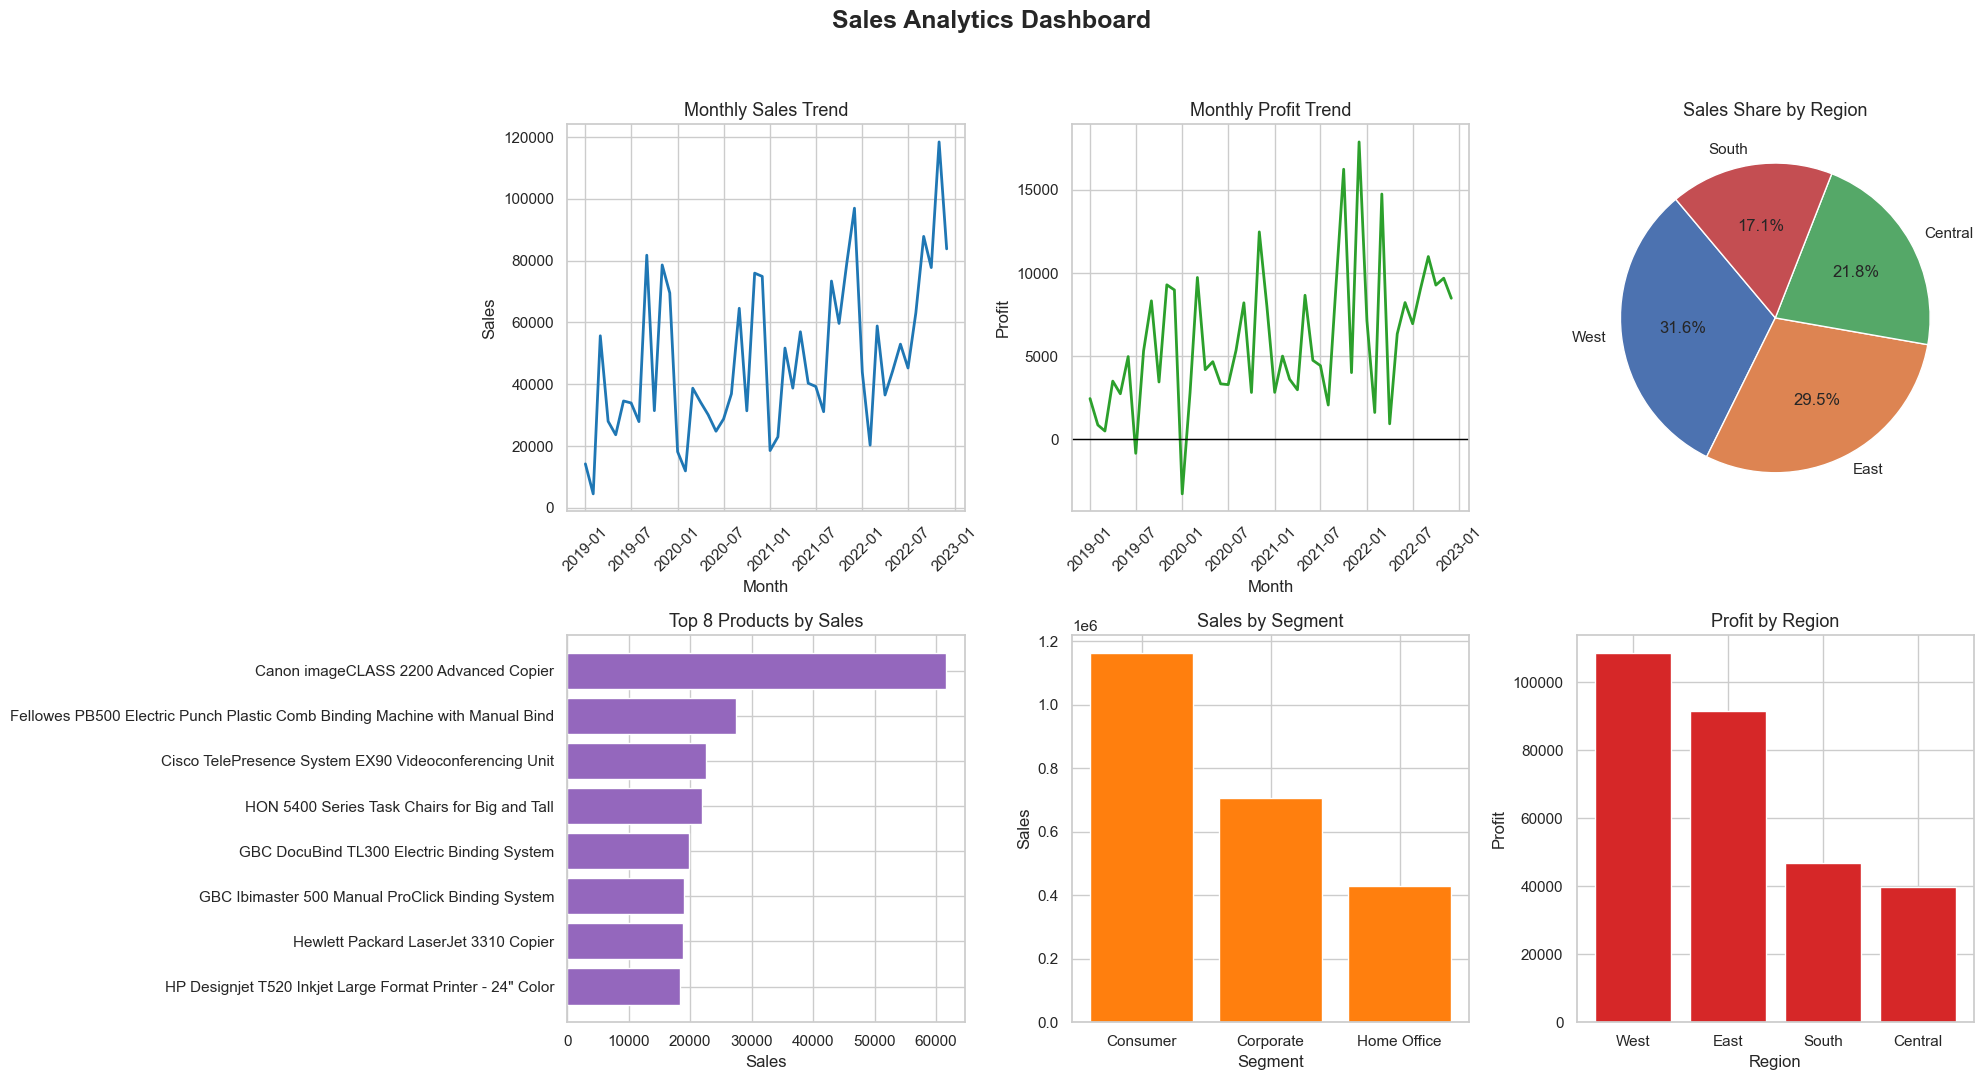

Saved: sales_visual_dashboard.png


In [32]:
# Additional visualization data
region_sales = df.groupby('Region', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
region_profit = df.groupby('Region', as_index=False)['Profit'].sum().sort_values('Profit', ascending=False)
segment_sales = df.groupby('Segment', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)

top_products_viz = (
    df.groupby('Product Name', as_index=False)['Sales']
      .sum()
      .sort_values('Sales', ascending=False)
      .head(8)
      .sort_values('Sales')
)

monthly_view = (
    df.groupby('Month', as_index=False)
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .sort_values('Month')
)

# Build dashboard grid
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Sales Analytics Dashboard', fontsize=18, fontweight='bold')

# 1) Monthly sales trend
axes[0, 0].plot(monthly_view['Month'], monthly_view['Sales'], color='tab:blue', linewidth=2)
axes[0, 0].set_title('Monthly Sales Trend')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Sales')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Monthly profit trend
axes[0, 1].plot(monthly_view['Month'], monthly_view['Profit'], color='tab:green', linewidth=2)
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Monthly Profit Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Profit')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3) Region sales share
axes[0, 2].pie(region_sales['Sales'], labels=region_sales['Region'], autopct='%1.1f%%', startangle=130)
axes[0, 2].set_title('Sales Share by Region')

# 4) Top products by sales
axes[1, 0].barh(top_products_viz['Product Name'], top_products_viz['Sales'], color='tab:purple')
axes[1, 0].set_title('Top 8 Products by Sales')
axes[1, 0].set_xlabel('Sales')

# 5) Sales by segment
axes[1, 1].bar(segment_sales['Segment'], segment_sales['Sales'], color='tab:orange')
axes[1, 1].set_title('Sales by Segment')
axes[1, 1].set_xlabel('Segment')
axes[1, 1].set_ylabel('Sales')

# 6) Profit by region
axes[1, 2].bar(region_profit['Region'], region_profit['Profit'], color='tab:red')
axes[1, 2].set_title('Profit by Region')
axes[1, 2].set_xlabel('Region')
axes[1, 2].set_ylabel('Profit')

plt.tight_layout(rect=[0, 0, 1, 0.95])
output_dashboard = source_path.parent / 'sales_visual_dashboard.png'
plt.savefig(output_dashboard, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved: {output_dashboard}')